## PCA Testing

In [1]:
import numpy as np
import pandas as pd
from Dimensionality_Reduction.PCA import PCA

df = pd.read_csv("Datasets/mnist.csv")
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [2]:
X = df.drop('label', axis=1)

In [3]:
X

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
explained_var = []
for i in range(1, X.shape[1]+1, 20):
    # print(i)
    pca = PCA(i)
    pca.fit(X)
    ratio = pca.get_explained_variance_ratio()
    explained_var.append(ratio)

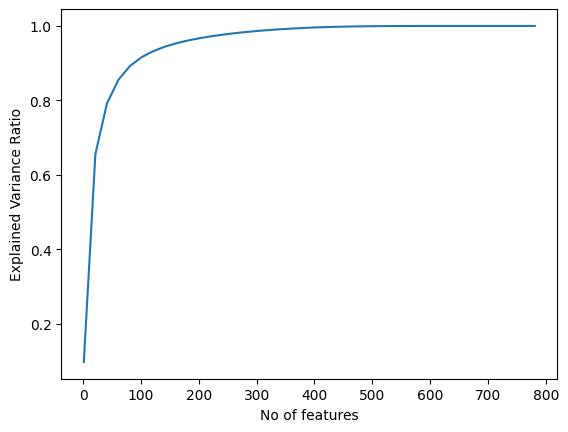

In [8]:
import matplotlib.pyplot as plt

n_features = [i for i in range(1, X.shape[1]+1, 20)]

plt.plot(n_features, explained_var)
plt.xlabel("No of features")
plt.ylabel("Explained Variance Ratio")
# plt.s
plt.show()

## Simple Linear Regression Testing

In [3]:
import pandas as pd

placement_df = pd.read_csv("Datasets/placement.csv", index_col=0)
placement_df.describe()

,cgpa,iq,placement
count,100.000000,100.000000,100.000000
mean,5.991000,123.580000,0.500000
std,1.143634,39.944198,0.502519
min,3.300000,37.000000,0.000000
25%,5.075000,101.500000,0.000000
50%,6.000000,127.500000,0.500000
75%,6.900000,149.000000,1.000000
max,8.500000,233.000000,1.000000


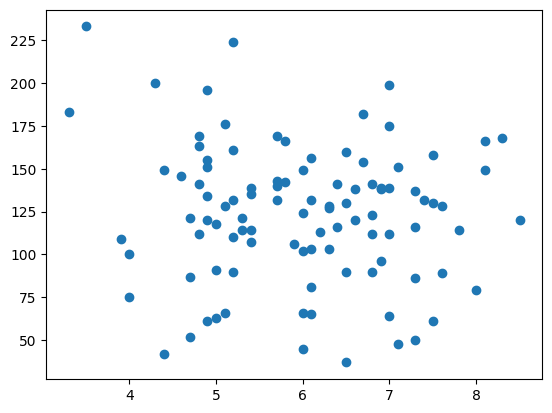

In [30]:
import matplotlib.pyplot as plt

plt.scatter(placement_df["cgpa"], placement_df["iq"])
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
X = placement_df["iq"].to_numpy()
y = placement_df["cgpa"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [5]:
from Regression.linear_regression import simple_linear_regressor
from sklearn.metrics import root_mean_squared_error
slr = simple_linear_regressor()
slr.fit(X_train, y_train)
y_pred = slr.predict(X_test)

print(root_mean_squared_error(y_test, y_pred))

1.2287728722305684


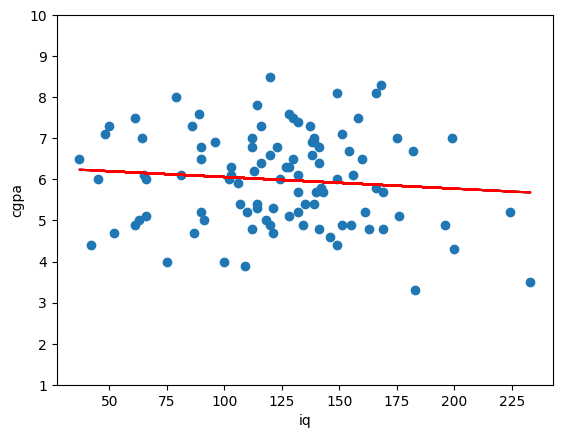

In [9]:

import matplotlib.pyplot as plt
from Regression.linear_regression import simple_linear_regressor
from sklearn.linear_model import LinearRegression 

lr = LinearRegression()
X_reshaped = X.reshape(-1, 1)
lr.fit(X_reshaped, y)
lr_y_pred = lr.predict(X_reshaped)

slr = simple_linear_regressor()
slr.fit(X, y)
slr_y_pred = slr.predict(X)

plt.scatter(x=X, y=y)
plt.plot(X, slr_y_pred)
plt.plot(X, lr_y_pred, color='red')
plt.xlabel("iq")
plt.ylabel("cgpa")
plt.ylim((1, 10))
plt.show()

In [1]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from Regression.linear_regression import multi_linear_regression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

X, y = make_regression(n_samples=100, n_features=4, n_targets=1, noise=0.5, random_state=12)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

mlr = multi_linear_regression()

mlr.fit(X_train, y_train)
mlr_y_pred = mlr.predict(X_test)

print("RMSE of mlr",root_mean_squared_error(y_test, mlr_y_pred))
print("R2 score of mlr", r2_score(y_test, mlr_y_pred))

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_y_pred = lr.predict(X_test)
print("RMSE of lr", root_mean_squared_error(y_test, lr_y_pred))
print("R2 score of lr", r2_score(y_test, lr_y_pred))

RMSE of mlr 0.5162422635828178
R2 score of mlr 0.9999860757070204
RMSE of lr 0.5162422635828405
R2 score of lr 0.9999860757070204


In [1]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from Regression.linear_regression import GDRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

X, y = make_regression(n_samples=100, n_features=4, n_targets=1, noise=0.5, random_state=12)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

gd_reg = GDRegressor()

gd_reg.fit(X_train, y_train, 0.01, 1000)
gd_reg_y_pred = gd_reg.predict(X_test)

print("RMSE of gd_reg",root_mean_squared_error(y_test, gd_reg_y_pred))
print("R2 score of gd_reg", r2_score(y_test, gd_reg_y_pred))

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_y_pred = lr.predict(X_test)
print("RMSE of lr", root_mean_squared_error(y_test, lr_y_pred))
print("R2 score of lr", r2_score(y_test, lr_y_pred))

RMSE of gd_reg 31.841986321786468
R2 score of gd_reg 0.9579417727672763
RMSE of lr 0.5418807791053059
R2 score of lr 0.9999878196952823


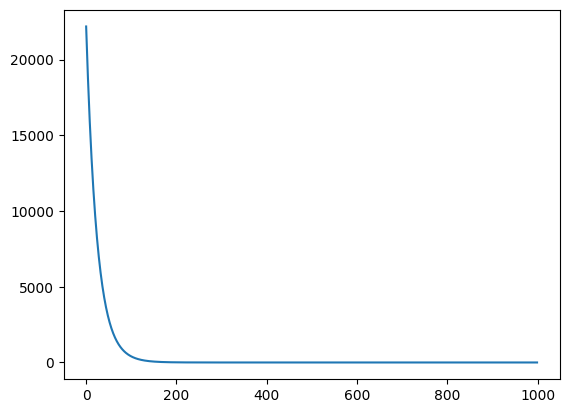

In [2]:
import matplotlib.pyplot as plt
errors = gd_reg.error_values()
plt.plot(errors)
plt.show()

In [1]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from Regression.linear_regression import SGDRegressor
from sklearn.metrics import root_mean_squared_error, r2_score


X, y = make_regression(n_samples=100, n_features=4, n_targets=1, noise=0.5, random_state=12)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

gd_reg = SGDRegressor()

gd_reg.fit(X_train, y_train, 0.01, 1000)
gd_reg_y_pred = gd_reg.predict(X_test)

print("RMSE of gd_reg",root_mean_squared_error(y_test, gd_reg_y_pred))
print("R2 score of gd_reg", r2_score(y_test, gd_reg_y_pred))

from sklearn.linear_model import SGDRegressor
lr = SGDRegressor()
lr.fit(X_train, y_train)
lr_y_pred = lr.predict(X_test)
print("RMSE of lr", root_mean_squared_error(y_test, lr_y_pred))
print("R2 score of lr", r2_score(y_test, lr_y_pred))

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 1)

In [5]:
import random
print(random.sample(range(1000), 10))

[728, 971, 627, 897, 996, 201, 899, 339, 679, 533]
